PCA from scratch retained 569 components
Sklearn PCA retained 569 components
Minimum Distance Classifier - Accuracy: 0.3836, Precision: 0.4241, Recall: 0.3836
Naïve Bayes - Accuracy: 0.2648, Precision: 0.4002, Recall: 0.2648
KNN - Accuracy: 0.4658, Precision: 0.3917, Recall: 0.4658
LDA - Accuracy: 0.3196, Precision: 0.4183, Recall: 0.3196


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


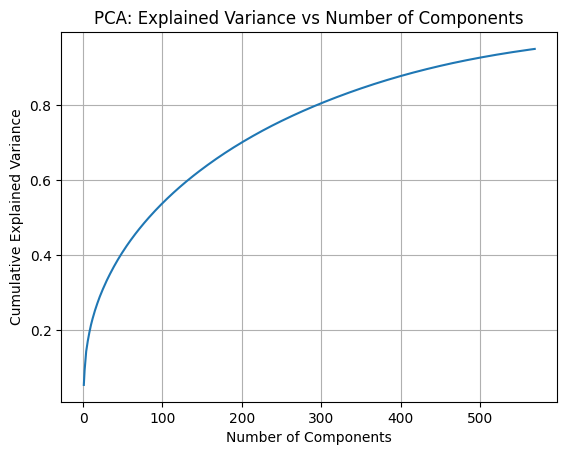

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, precision_score, recall_score
from scipy.spatial.distance import pdist, squareform
from scipy.linalg import eigh

# Load dataset - gotta get that data in first
df = pd.read_csv("Lung.csv")

# Preprocess data - standardizing because machine learning loves everything in the same scale
X = df.iloc[:, :-1].values  # Features
y = df.iloc[:, -1].values   # Labels
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA from Scratch - done manually
def pca_from_scratch(X, variance_threshold=0.95):
    # Step 1: Compute covariance matrix
    cov_matrix = np.cov(X, rowvar=False)
    # Step 2: Get eigenvalues & eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    # Step 3: Sort 'em in descending order
    sorted_indices = np.argsort(eigenvalues)[::-1]
    eigenvalues, eigenvectors = eigenvalues[sorted_indices], eigenvectors[:, sorted_indices]
    # Step 4: Calculate explained variance ratio
    explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
    # Step 5: Pick enough components to keep 95% variance
    num_components = np.argmax(np.cumsum(explained_variance_ratio) >= variance_threshold) + 1
    # Step 6: Project data onto the top components
    W = eigenvectors[:, :num_components]
    return np.dot(X, W), num_components

X_pca_scratch, n_components_scratch = pca_from_scratch(X_scaled)
print(f"PCA from scratch retained {n_components_scratch} components")

# Scikit-learn PCA - because why reinvent the wheel?
pca = PCA(n_components=0.95)
X_pca_sklearn = pca.fit_transform(X_scaled)
print(f"Sklearn PCA retained {pca.n_components_} components")

# Kernel PCA - adding some spice with kernels
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.1)
X_kpca = kpca.fit_transform(X_scaled)

# Train-test split - to make sure our model doesn't cheat
X_train, X_test, y_train, y_test = train_test_split(X_pca_sklearn, y, test_size=0.2, random_state=42)

# Minimum Distance Classifier - closest mean wins
def min_distance_classifier(X_train, y_train, X_test):
    class_means = {label: X_train[y_train == label].mean(axis=0) for label in np.unique(y_train)}
    return np.array([min(class_means, key=lambda label: np.linalg.norm(x - class_means[label])) for x in X_test])

y_pred_mdc = min_distance_classifier(X_train, y_train, X_test)

# Train classifiers - let’s see which one’s the best
nb, knn, lda = GaussianNB(), KNeighborsClassifier(n_neighbors=5), LinearDiscriminantAnalysis()
nb.fit(X_train, y_train)
knn.fit(X_train, y_train)
lda.fit(X_train, y_train)

# Predictions - time to see how they do
y_pred_nb, y_pred_knn, y_pred_lda = nb.predict(X_test), knn.predict(X_test), lda.predict(X_test)

# Function to evaluate models - keeping score
def evaluate_model(y_true, y_pred, name):
    print(f"{name} - Accuracy: {accuracy_score(y_true, y_pred):.4f}, Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}, Recall: {recall_score(y_true, y_pred, average='weighted'):.4f}")

evaluate_model(y_test, y_pred_mdc, "Minimum Distance Classifier")
evaluate_model(y_test, y_pred_nb, "Naïve Bayes")
evaluate_model(y_test, y_pred_knn, "KNN")
evaluate_model(y_test, y_pred_lda, "LDA")

# Plot variance explained - our visuals
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA: Explained Variance vs Number of Components")
plt.grid()
plt.show()

